In [2]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
input_filename = 'cardio_train_properly_separated_comma.csv'
df = pd.read_csv(input_filename, delimiter=',')

In [4]:
df.head(10)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
5,8,21914,1,151,67.0,120,80,2,2,0,0,0,0
6,9,22113,1,157,93.0,130,80,3,1,0,0,1,0
7,12,22584,2,178,95.0,130,90,3,3,0,0,1,1
8,13,17668,1,158,71.0,110,70,1,1,0,0,1,0
9,14,19834,1,164,68.0,110,60,1,1,0,0,0,0


In [5]:
# count null values 
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [6]:
df["age_years"] = (df["age"] / 365).astype(int)


In [7]:
df = df.drop("age", axis=1)

In [8]:
df.head(10)

,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47
5,8,1,151,67.0,120,80,2,2,0,0,0,0,60
6,9,1,157,93.0,130,80,3,1,0,0,1,0,60
7,12,2,178,95.0,130,90,3,3,0,0,1,1,61
8,13,1,158,71.0,110,70,1,1,0,0,1,0,48
9,14,1,164,68.0,110,60,1,1,0,0,0,0,54


In [9]:
# Add BMI
df["bmi"] = df["weight"] / (df["height"]/100)**2

In [10]:
df.head(10)

,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177
5,8,1,151,67.0,120,80,2,2,0,0,0,0,60,29.384676
6,9,1,157,93.0,130,80,3,1,0,0,1,0,60,37.729725
7,12,2,178,95.0,130,90,3,3,0,0,1,1,61,29.983588
8,13,1,158,71.0,110,70,1,1,0,0,1,0,48,28.440955
9,14,1,164,68.0,110,60,1,1,0,0,0,0,54,25.282570


In [11]:
print("Min height:", df["height"].min())
print("Max height:", df["height"].max())

print("Min weight:", df["weight"].min())
print("Max weight:", df["weight"].max())


Min height: 55
Max height: 250
Min weight: 10.0
Max weight: 200.0


In [12]:
# Clean height
df = df[(df["height"] >= 130) & (df["height"] <= 220)]

# Clean weight
df = df[(df["weight"] >= 30) & (df["weight"] <= 200)]


In [13]:
print("Min height:", df["height"].min())
print("Max height:", df["height"].max())

print("Min weight:", df["weight"].min())
print("Max weight:", df["weight"].max())


Min height: 130
Max height: 207
Min weight: 30.0
Max weight: 200.0


In [14]:
df['ap_hi'].min(), df['ap_hi'].max()
df['ap_lo'].min(), df['ap_lo'].max()


(-70, 11000)

In [15]:
df = df[(df["ap_hi"] > 0) & (df["ap_lo"] > 0)]

In [16]:
df['ap_hi'].min(), df['ap_hi'].max()
df['ap_lo'].min(), df['ap_lo'].max()

(1, 11000)

In [17]:
df = df[(df["ap_hi"] >= 80) & (df["ap_hi"] <= 250)]
df = df[(df["ap_lo"] >= 40) & (df["ap_lo"] <= 200)]

In [18]:
df['ap_hi'].min(), df['ap_hi'].max()
df['ap_lo'].min(), df['ap_lo'].max()


(40, 190)

In [19]:
df["cholesterol"].unique()


array([1, 3, 2], dtype=int64)

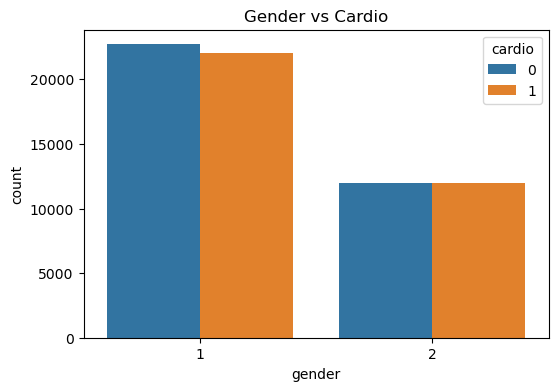

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='cardio', data=df)
plt.title("Gender vs Cardio")
plt.show()

<h3>Gender vs Cardio</h3>
<p>
The bar chart compares heart disease occurrence between genders.
In this dataset, gender does not show any strong influence on heart disease.
Both males and females have almost the same ratio of cardio cases.
Therefore, gender is not a significant predictor of heart disease.
</p>


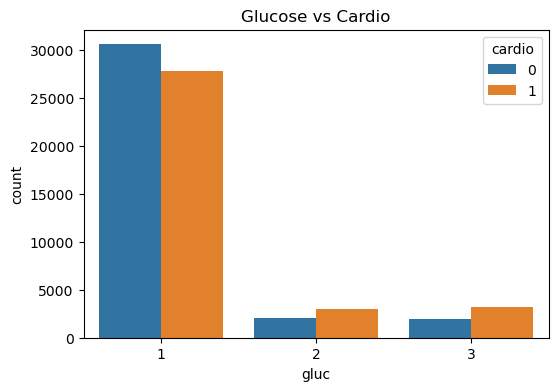

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x='gluc', hue='cardio', data=df)
plt.title("Glucose vs Cardio")
plt.show()

<h3>Glucose vs Cardio</h3>
<p>
This chart shows the relationship between glucose levels and heart disease.
Most people in the dataset have normal glucose levels (gluc = 1), and among them,
cardio cases are slightly fewer compared to non-cardio.
However, when glucose levels increase to 2 or 3, the number of cardio cases becomes higher.
This indicates that elevated glucose levels are associated with a higher risk of heart disease.
Although not the strongest factor, glucose is still a meaningful predictor.
</p>


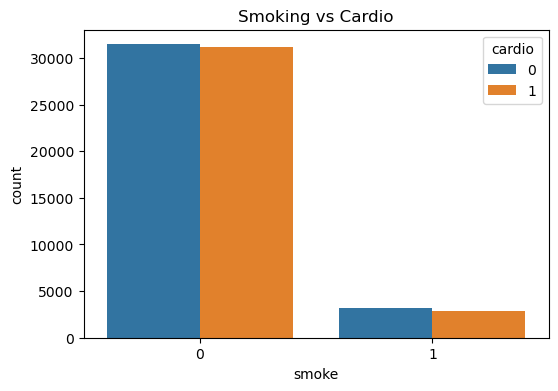

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x='smoke', hue='cardio', data=df)
plt.title("Smoking vs Cardio")
plt.show()

<h3>Smoking vs Cardio</h3>
<p>
This chart compares smoking status with the occurrence of heart disease. 
Most people in the dataset are non-smokers, and among them, the number of cardio and non-cardio cases is almost the same. 
For smokers, both cardio and non-cardio counts are lower due to fewer smokers in the dataset. 
Overall, smoking does not show a strong relationship with heart disease in this dataset, 
which is also confirmed by the very low correlation value in the heatmap.
</p>


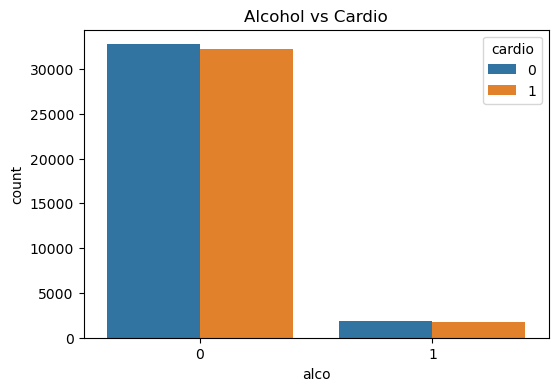

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x='alco', hue='cardio', data=df)
plt.title("Alcohol vs Cardio")
plt.show()

<h3>Alcohol vs Cardio</h3>
<p>
This chart shows the comparison between alcohol consumption and heart disease.
Most people in the dataset do not drink alcohol, and for them, the number of cardio and 
non-cardio cases is almost the same. Among alcohol drinkers, the number of cases is much smaller,
and both categories (cardio and non-cardio) also appear nearly equal.
Overall, alcohol consumption does not show a strong relationship with heart disease in this dataset,
which is confirmed by the very low correlation value between alcohol and cardio.
</p>


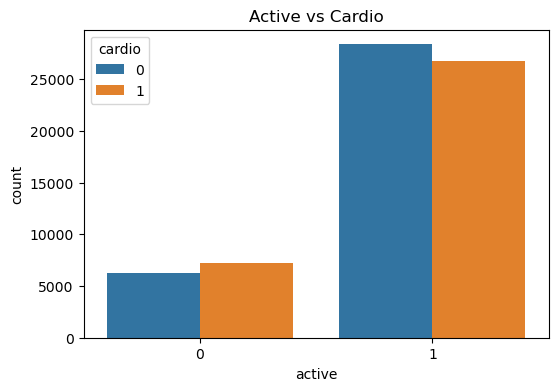

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x='active', hue='cardio', data=df)
plt.title("Active vs Cardio")
plt.show()

<h3>Active vs Cardio</h3>
<p>
This chart shows the comparison between physical activity and heart disease.
Most people in the dataset are physically active. Among active individuals,
the number of non-cardio cases is slightly higher than cardio cases,
indicating a small reduction in heart disease risk for active people.
For non-active individuals, cardio cases are slightly higher.
However, the difference is small, meaning that physical activity has only
a minor effect on heart disease risk in this dataset.
This is consistent with the very weak negative correlation between activity and cardio.
</p>


Before: 68664 After: 68568


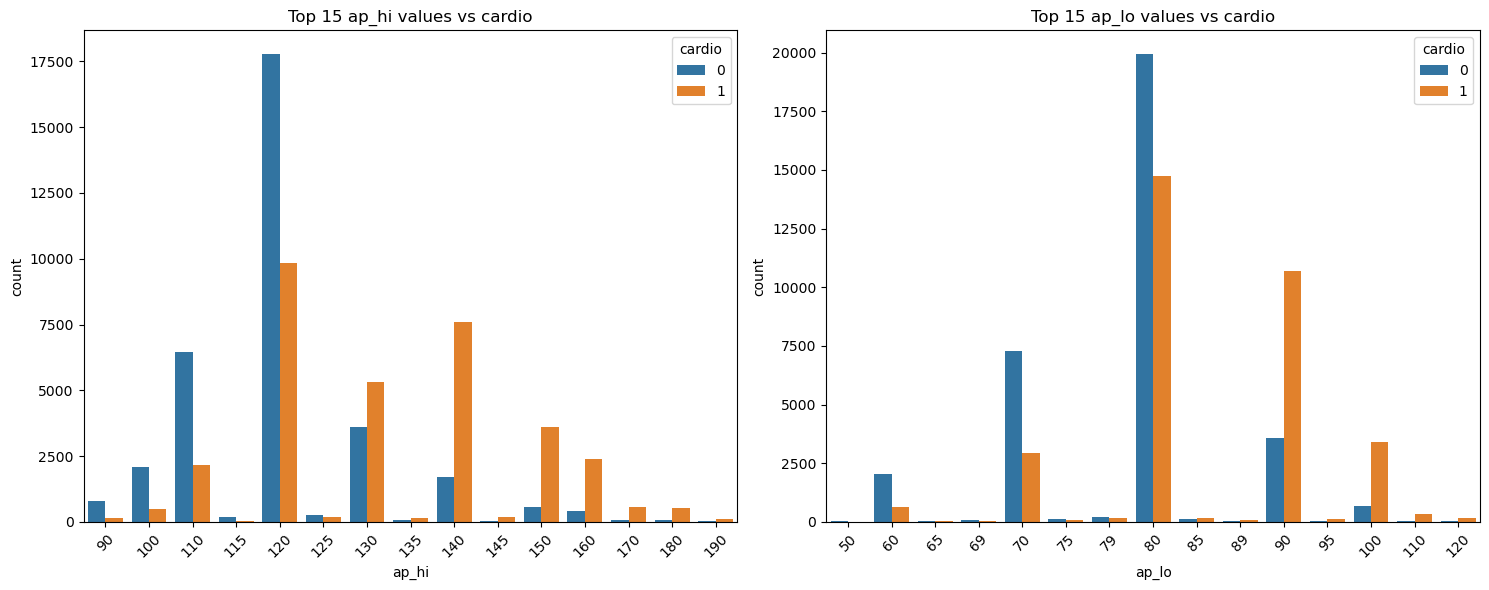

In [25]:
#ap high low , vs cardio 
# CODE: cleaning function (adapt from earlier)
AP_HI_MIN, AP_HI_MAX = 70, 250
AP_LO_MIN, AP_LO_MAX = 40, 140

def clean_bp(df):
    df = df.copy()
    df = df.dropna(subset=['ap_hi','ap_lo','cardio'])
    df['ap_hi'] = df['ap_hi'].astype(int)
    df['ap_lo'] = df['ap_lo'].astype(int)
    mask = (
        (df['ap_hi'] >= AP_HI_MIN) & (df['ap_hi'] <= AP_HI_MAX) &
        (df['ap_lo'] >= AP_LO_MIN) & (df['ap_lo'] <= AP_LO_MAX)
    )
    df = df[mask]
    df = df[df['ap_lo'] <= df['ap_hi']]
    return df

df_clean = clean_bp(df)
print("Before:", len(df), "After:", len(df_clean))

top_hi = df_clean['ap_hi'].value_counts().nlargest(15).index
top_lo = df_clean['ap_lo'].value_counts().nlargest(15).index

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.countplot(x='ap_hi', hue='cardio', data=df_clean[df_clean['ap_hi'].isin(top_hi)])
plt.title('Top 15 ap_hi values vs cardio')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.countplot(x='ap_lo', hue='cardio', data=df_clean[df_clean['ap_lo'].isin(top_lo)])
plt.title('Top 15 ap_lo values vs cardio')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


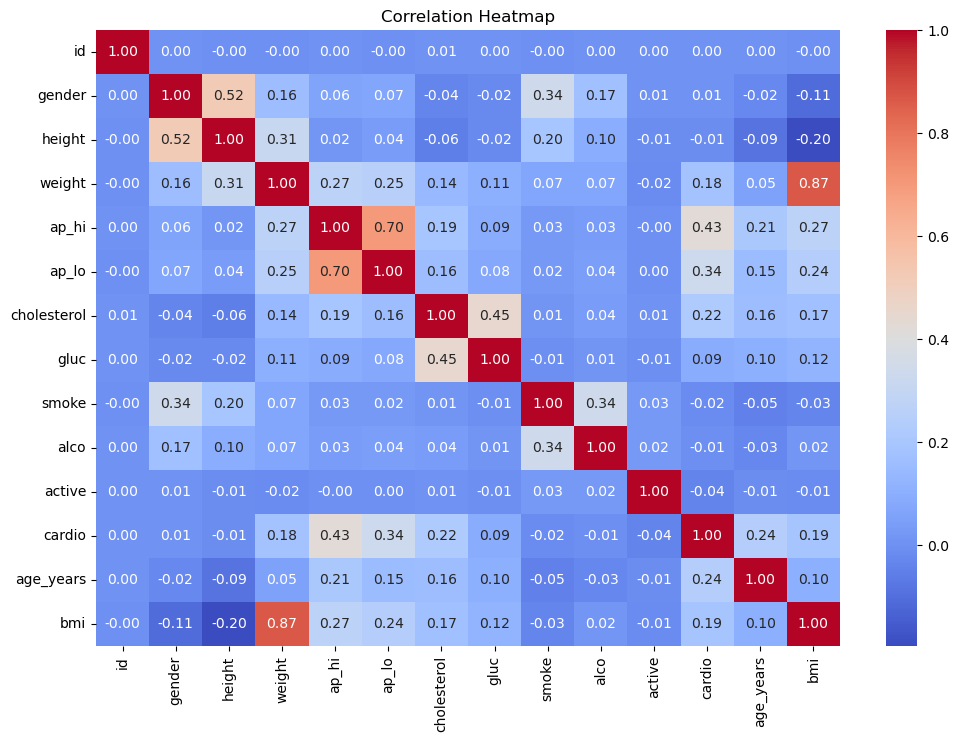

In [26]:
# Heatmap of correlations
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


<h2>Correlation Heatmap Analysis</h2>

<p>
The correlation heatmap illustrates the linear relationship between various health parameters and the target variable 
<strong>cardio</strong> (presence of cardiovascular disease).
</p>

<h3>Top Predictors of Heart Disease</h3>
<ul>
  <li>
    <strong>Systolic Blood Pressure (ap_hi): 0.43</strong> – 
    Shows the strongest positive correlation with heart disease. 
    Higher systolic blood pressure significantly increases cardiovascular risk.
  </li>
  <li>
    <strong>Diastolic Blood Pressure (ap_lo): 0.34</strong> – 
    Moderately correlated with cardio, indicating its importance in heart health.
  </li>
  <li>
    <strong>Age (age_years): 0.24</strong> – 
    Risk of cardiovascular disease increases with age.
  </li>
  <li>
    <strong>Cholesterol: 0.22</strong> – 
    Elevated cholesterol levels are associated with a higher likelihood of heart disease.
  </li>
</ul>

<h3>Moderate Predictors</h3>
<ul>
  <li>
    <strong>BMI: 0.19</strong> – 
    Higher body mass index increases cardiovascular risk.
  </li>
  <li>
    <strong>Weight: 0.18</strong> – 
    Positively correlated with cardio and closely related to BMI.
  </li>
  <li>
    <strong>Glucose: 0.09</strong> – 
    Shows a weak to moderate relationship with heart disease.
  </li>
</ul>

<h3>Weak or No Effect</h3>
<ul>
  <li>
    <strong>Gender, Smoking, Alcohol Intake, Physical Activity, Height</strong> – 
    These features show very low correlation with the target variable, 
    indicating minimal linear influence on cardiovascular disease in this dataset.
  </li>
</ul>


In [27]:
#correlation matrix
correlation_matrix = df.corr()
print(correlation_matrix)

                   id    gender    height    weight     ap_hi     ap_lo  \
id           1.000000  0.002856 -0.002342 -0.001742  0.001159 -0.000486   
gender       0.002856  1.000000  0.521938  0.157103  0.061528  0.066585   
height      -0.002342  0.521938  1.000000  0.311073  0.017348  0.035138   
weight      -0.001742  0.157103  0.311073  1.000000  0.268612  0.249351   
ap_hi        0.001159  0.061528  0.017348  0.268612  1.000000  0.700664   
ap_lo       -0.000486  0.066585  0.035138  0.249351  0.700664  1.000000   
cholesterol  0.005963 -0.036509 -0.055395  0.141339  0.194027  0.158973   
gluc         0.002413 -0.021082 -0.020975  0.106991  0.092983  0.076495   
smoke       -0.003282  0.338811  0.196067  0.066986  0.027246  0.024379   
alco         0.000631  0.171291  0.098240  0.068382  0.033134  0.042959   
active       0.003904  0.005906 -0.009580 -0.017841 -0.001816  0.000153   
cardio       0.003540  0.007268 -0.012365  0.179883  0.425140  0.335852   
age_years    0.003805 -0.

In [28]:
# Calculate correlation matrix ensuring numeric columns only
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()


In [29]:
strong_predictors = correlation_matrix["cardio"].abs().sort_values(ascending=False)[1:]
print(strong_predictors)

ap_hi          0.425140
ap_lo          0.335852
age_years      0.239364
cholesterol    0.221430
bmi            0.191246
weight         0.179883
gluc           0.090010
active         0.037424
smoke          0.016193
height         0.012365
alco           0.007788
gender         0.007268
id             0.003540
Name: cardio, dtype: float64


## 3. Model Creation

### 3.1 Selection of Algorithm
Logistic Regression is chosen as the target variable (cardio) is binary.
The model is implemented from scratch without using any machine learning library.


In [30]:
import numpy as np

# Feature selection
X = df[['ap_hi', 'ap_lo', 'age_years', 'cholesterol', 'bmi', 'weight']]
y = df['cardio']
X_np = X.values          # features
y_np = y.values.reshape(-1, 1)  # labels


In [31]:
split_ratio = 0.8
split_index = int(len(X_np) * split_ratio)

X_train = X_np[:split_index]
X_test  = X_np[split_index:]

y_train = y_np[:split_index]
y_test  = y_np[split_index:]


In [32]:
X_train = (X_train - X_train.mean(axis=0)) / X_train.std(axis=0)
X_test  = (X_test - X_test.mean(axis=0)) / X_test.std(axis=0)


In [33]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [34]:
m, n = X_train.shape
weights = np.zeros((n, 1))
bias = 0
learning_rate = 0.01
epochs = 1000


In [35]:
for _ in range(epochs):
    z = np.dot(X_train, weights) + bias
    y_pred = sigmoid(z)

    dw = (1/m) * np.dot(X_train.T, (y_pred - y_train))
    db = (1/m) * np.sum(y_pred - y_train)

    weights -= learning_rate * dw
    bias -= learning_rate * db


In [36]:
def predict(X):
    z = np.dot(X, weights) + bias
    return (sigmoid(z) >= 0.5).astype(int)


In [37]:
y_pred = predict(X_test)
accuracy = np.mean(y_pred == y_test)
print("Accuracy (Logistic Regression ):", accuracy)


Accuracy (Logistic Regression ): 0.7203815626592879


In [38]:
# Identify strong predictors based on correlation
# Ensure we only correlate numeric columns
numeric_df = df.select_dtypes(include=['number'])
correlation = numeric_df.corr()
# Drop 'cardio' itself from predictors
strong_predictors = correlation['cardio'].drop('cardio').sort_values(ascending=False)
print(strong_predictors)


ap_hi          0.425140
ap_lo          0.335852
age_years      0.239364
cholesterol    0.221430
bmi            0.191246
weight         0.179883
gluc           0.090010
gender         0.007268
id             0.003540
alco          -0.007788
height        -0.012365
smoke         -0.016193
active        -0.037424
Name: cardio, dtype: float64


In [39]:
# Split data and train baseline Random Forest
import os
import joblib
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay

X = df[strong_predictors.index]
y = df["cardio"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
 )

baseline_rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
baseline_rf.fit(X_train, y_train)
print("✓ Baseline Random Forest trained")

✓ Baseline Random Forest trained


In [40]:
# Simple evaluation helper
def eval_binary(model, X, y):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    metrics = {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall": recall_score(y, y_pred, zero_division=0),
        "F1": f1_score(y, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y, y_proba)
    }
    return metrics, y_pred, y_proba

print("✓ Evaluation helper ready")

✓ Evaluation helper ready


In [41]:
# Evaluate baseline model
baseline_metrics, baseline_pred, baseline_proba = eval_binary(baseline_rf, X_test, y_test)
correct = (baseline_pred == y_test).sum()
incorrect = (baseline_pred != y_test).sum()

print("Correct:", int(correct))
print("Incorrect:", int(incorrect))

pd.DataFrame([baseline_metrics], index=["Random Forest (Baseline)"])

Correct: 9877
Incorrect: 3856


,Accuracy,Precision,Recall,F1,ROC AUC
Random Forest (Baseline),0.719216,0.724238,0.698882,0.711334,0.781161


Baseline prediction check: correct vs incorrect.

In [ ]:
# Simple hyperparameter tuning
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
gs = GridSearchCV(rf, param_grid, cv=3, scoring="roc_auc", n_jobs=-1)
gs.fit(X_train, y_train)

tuned_rf = gs.best_estimator_
print("✓ Best params:", gs.best_params_)
print(f"✓ Best CV ROC AUC: {gs.best_score_:.4f}")

✓ Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 400}
✓ Best CV ROC AUC: 0.7994


In [43]:
# Evaluate tuned model and compare
tuned_metrics, tuned_pred, tuned_proba = eval_binary(tuned_rf, X_test, y_test)
comparison = pd.DataFrame(
    [baseline_metrics, tuned_metrics],
    index=["Random Forest (Baseline)", "Random Forest (Tuned)"]
)
comparison

,Accuracy,Precision,Recall,F1,ROC AUC
Random Forest (Baseline),0.719216,0.724238,0.698882,0.711334,0.781161
Random Forest (Tuned),0.731013,0.757807,0.671080,0.711812,0.800544


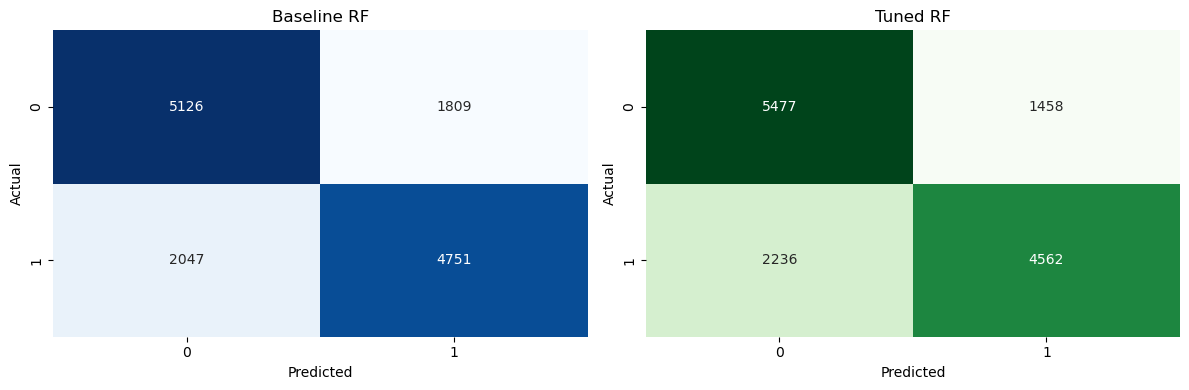

In [44]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_base = confusion_matrix(y_test, baseline_pred)
sns.heatmap(cm_base, annot=True, fmt="d", cmap="Blues", ax=axes[0], cbar=False)
axes[0].set_title("Baseline RF")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

cm_tuned = confusion_matrix(y_test, tuned_pred)
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Greens", ax=axes[1], cbar=False)
axes[1].set_title("Tuned RF")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

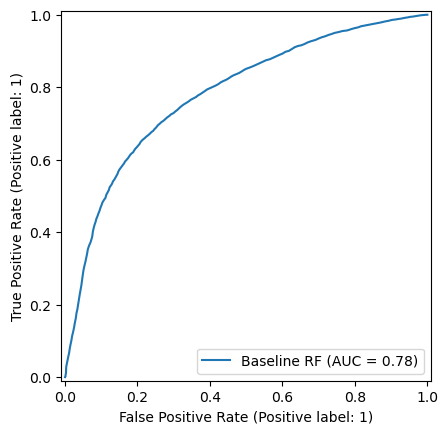

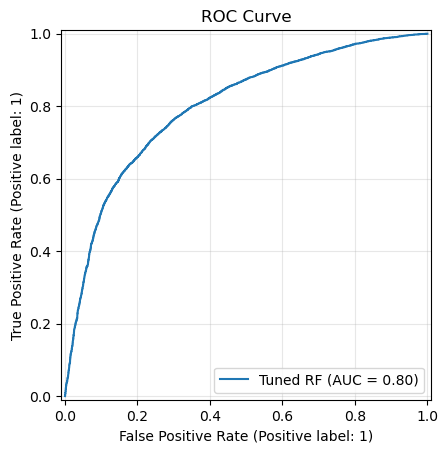

In [45]:
# ROC curve
plt.figure(figsize=(6, 4))
RocCurveDisplay.from_predictions(y_test, baseline_proba, name="Baseline RF")
RocCurveDisplay.from_predictions(y_test, tuned_proba, name="Tuned RF")
plt.title("ROC Curve")
plt.grid(alpha=0.3)
plt.show()

<Figure size 600x400 with 0 Axes>

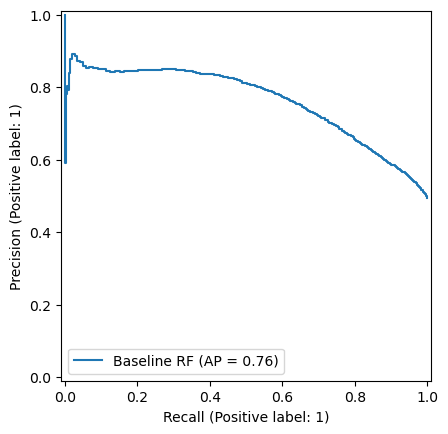

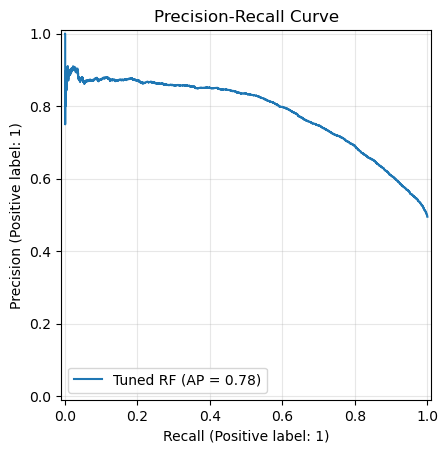

In [46]:
# Precision-Recall curve
plt.figure(figsize=(6, 4))
PrecisionRecallDisplay.from_predictions(y_test, baseline_proba, name="Baseline RF")
PrecisionRecallDisplay.from_predictions(y_test, tuned_proba, name="Tuned RF")
plt.title("Precision-Recall Curve")
plt.grid(alpha=0.3)
plt.show()

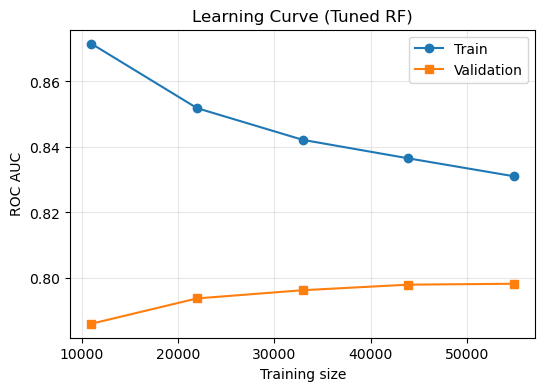

In [47]:
# Learning curve (tuned model)
train_sizes, train_scores, val_scores = learning_curve(
    tuned_rf, X, y, cv=5, scoring="roc_auc",
    train_sizes=np.linspace(0.2, 1.0, 5), n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_mean, marker="o", label="Train")
plt.plot(train_sizes, val_mean, marker="s", label="Validation")
plt.xlabel("Training size")
plt.ylabel("ROC AUC")
plt.title("Learning Curve (Tuned RF)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

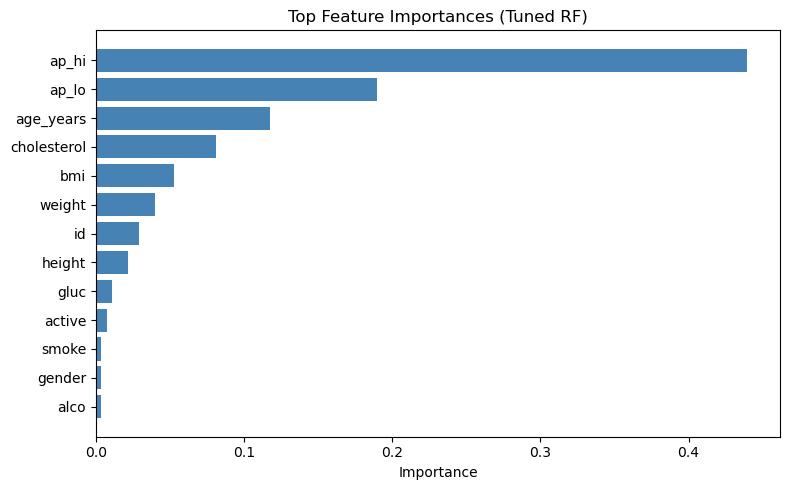

In [48]:
# Feature importance (tuned model)
feature_names = np.array(X.columns)
importances = tuned_rf.feature_importances_
top_n = min(15, len(importances))
top_idx = np.argsort(importances)[-top_n:][::-1]

plt.figure(figsize=(8, 5))
plt.barh(range(top_n), importances[top_idx], color="steelblue")
plt.yticks(range(top_n), feature_names[top_idx])
plt.xlabel("Importance")
plt.title("Top Feature Importances (Tuned RF)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [49]:
# Save model artifacts
os.makedirs("artifacts", exist_ok=True)
joblib.dump(baseline_rf, "artifacts/random_forest_baseline.joblib")
joblib.dump(tuned_rf, "artifacts/best_random_forest_tuned.joblib")
print("✓ Saved models to artifacts/")

✓ Saved models to artifacts/
